___
# <font color= #003366> **Variational Autoencoder for T-Shirt Image Generation** </font>
- <Strong> Subject: </Strong>  <font color="blue">`Deep Learning` </font>
- <Strong> Project 1: </Strong>  <font color="blue">`Autoencoders` </font>

<div style="display: flex; align-items: center;">
    <div style="flex: 1;">
        <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Principal.jpg" width="300">
    </div>
</div>

___

<img src="https://www.cs.us.es/~fsancho/Blog/posts/img/vae3.png" width="800">

## <font color=  #003366> **Variational Autoencoder**</font>

A Variational Autoencoder, or VAE, is a generative model from deep learning that can learn to compress images into a smaller representation and then recreate them. In this project, we are using a VAE to generate new images by learning patterns from our 297 original images, so it can create images that look similar but are not exactly the same.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


We connect to Google Drive so we can run the notebook using Colab, so we can use GPU and so the experiments run faster.

## <font color=  #003366> **Required Libraries**</font>

In [ ]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, UpSampling2D
from sklearn.metrics import mean_squared_error

folder = "/content/drive/MyDrive/deep_learning_project1/final_tshirts"

## <font color=  #003366> **Data Loading**</font>


In [ ]:
def load_images(folder):
    images = []
    for file in os.listdir(folder):
        if file.endswith((".jpg", ".jpeg", ".png")):
            img = load_img(os.path.join(folder, file))
            img = img_to_array(img)
            images.append(img)
    return np.array(images, dtype="uint8")

X = load_images(folder)
print("Number of images:", len(X))
print("Shape:", X.shape)

Number of images: 293
Shape: (293, 64, 64, 3)


This function iterates through the dataset folder and loads all images with valid extensions (.jpg, .jpeg, .png).

Each image is:
- Loaded as RGB
- Converted to a NumPy array
- Stored in a list
- Converted into a NumPy array of shape:
(297, 64, 64, 3)

Which means that we have 297 total images, of 64x64 in RGB channels

## <font color=  #003366> **Train/Test**</font>


In [ ]:
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (234, 64, 64, 3)
Test: (59, 64, 64, 3)


The dataset is split into 80% training and 20% testing, so we can train and evaluate.

## <font color=  #003366> **Visualizations Original Images**</font>


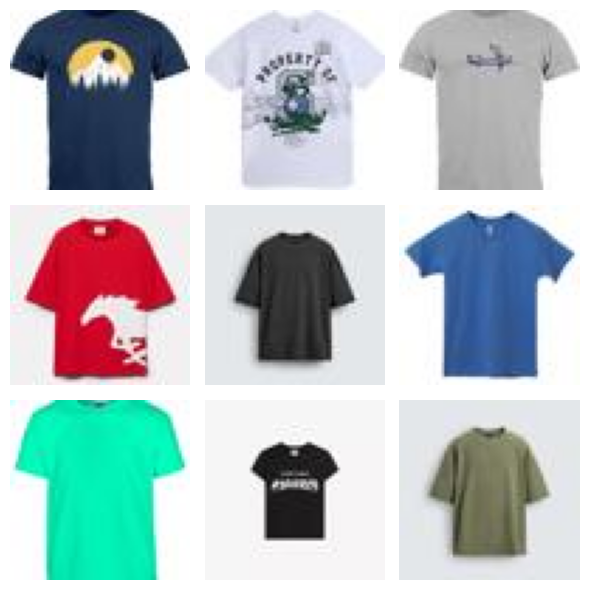

In [ ]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Here we can see some visualizations of the original images in the dataset, we can see that we have different colors, sizes and designs.

## <font color=  #003366> **Normalization**</font>

In [ ]:
X_train_norm = X_train.astype("float32") / 255.
X_test_norm = X_test.astype("float32") / 255.

We convert pixel values from integers in the range [0, 255] to floating values in the range [0, 1].

The normalization is performed by dividing each pixel value by 255.

## <font color=  #003366> **Defining the Latent Space**</font>

In [ ]:
latent_dim = 32

Here, we define the dimensionality of the latent space.

The latent dimension controls how much compressed information the model can store about each image.

A smaller latent dimension forces stronger compression, while a larger dimension allows more detailed representations.

In this implementation, we use a latent dimension of 32. Which means that each 64×64×3 image (12,288 values) is compressed into 32 numbers.

**Beta is important because:**

The total loss becomes:

Reconstruction Loss + β × KL Loss

This means:
- If β is large then the model focuses more on organizing the latent space.
- If β is small then the model focuses more on reconstruction quality.

So β controls the balance between:
- Reconstruction quality
- Latent space regularization

## <font color=  #003366> **Sampling Layer (Reparameterization Trick)**</font>

In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        z = z_mean + tf.exp(0.5 * z_log_var) * epsilon

        # KL Divergence
        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        self.add_loss(kl_loss)
        return z

This is what makes the model a Variational Autoencoder.

Instead of encoding into a single vector, the encoder outputs:
- z_mean
- z_log_var

These define a Gaussian distribution.

This custom layer implements the reparameterization trick, which is a key component of Variational Autoencoders.

Instead of directly sampling from a normal distribution, we compute:

z = μ + σ * ε

Where:
- μ is the latent mean
- σ is derived from the log variance
- ε is sampled from a standard normal distribution

This formulation allows backpropagation through the sampling process.

Additionally, this layer computes and adds the KL Divergence loss, which regularizes the latent space to follow a normal distribution, which enables meaningful sampling

## <font color=  #003366> **Encoder**</font>

In [ ]:
encoder_inputs = layers.Input(shape=(64, 64, 3))

x = layers.Conv2D(32, 3, activation='relu', padding='same')(encoder_inputs)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)

z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(encoder_inputs, z, name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 16,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 8, 8, 128) │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 8192)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  2,097,408 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      8,224 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      8,224 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 32)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,207,104 (8.42 MB)

 Trainable params: 2,207,104 (8.42 MB)

 Non-trainable params: 0 (0.00 B)

The encoder is responsible for compressing the input image into a smaller latent representation.
The original image has size 64×64×3 (12,288 values), and the encoder reduces it step by step until it becomes a 32 dimensional latent vector.

The encoder has:
- 3 convolutional layers
- 3 max-pooling layers
- 1 flatten layer
- 1 dense hidden layer
- 2 dense layers to produce the latent variables (z_mean and z_log_var)

Each convolution layer extracts visual features from the image, such as edges, shapes, and patterns like sleeves or collars. As we go deeper into the network, the number of filters increases (32 → 64 → 128), allowing the model to learn more complex features.

MaxPooling layers reduce the spatial size of the image (64×64 → 32×32 → 16×16 → 8×8). This helps reduce computation and forces the network to keep only the most important information.

After the convolution layers, the feature maps are flattened into a vector and passed through a dense layer. This dense layer helps combine all extracted features before compressing them into the latent space.

Finally, the encoder outputs a 32 dimensional latent representation. This is the bottleneck of the model and represents a compressed version of the image.

This means the encoder reduces 12,288 values into only 32 values, achieving strong dimensionality reduction.

**ReLU** activation is used in all hidden layers because it helps the model learn complex patterns efficiently because it introduces nonlinearity. It is simple and works very well in convolutional neural networks.

## <font color=  #003366> **Decoder**</font>

In [ ]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(8 * 8 * 128, activation="relu")(latent_inputs)
x = layers.Reshape((8, 8, 128))(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.UpSampling2D(2)(x)

decoder_outputs = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

decoder = Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8192)           │       270,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 511,043 (1.95 MB)

 Trainable params: 511,043 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

The decoder does the opposite operation of the encoder. It takes the 32 dimensional latent vector and reconstructs the image back to its original size (64×64×3).

The decoder has:
- 1 dense layer
- 1 reshape layer
- 3 convolutional layers
- 3 upsampling layers
- 1 final convolution layer with sigmoid activation

First, the latent vector is expanded using a dense layer and reshaped into a small feature map (8×8×128). Then, the model gradually increases the spatial resolution using upsampling layers (8×8 → 16×16 → 32×32 → 64×64).

Convolution layers refine the image at each stage and help reconstruct details.

The final layer uses sigmoid activation because the images were normalized to values between 0 and 1.

## <font color=  #003366> **Variational Autoencoder Model**</font>

In [ ]:
outputs = decoder(encoder(encoder_inputs))
vae = Model(encoder_inputs, outputs, name="VAE_Tshirts")

In this step, we connect the encoder and decoder to form the full VAE model.

The encoder compresses the image into a latent distribution.
A latent sample is drawn using the sampling layer.
The decoder reconstructs the image from that sample.

The KL divergence loss is automatically added during the sampling process.

The architecture is approximately symmetrical: the encoder gradually reduces spatial dimensions while increasing feature depth, and the decoder gradually increases spatial dimensions while reducing feature depth. This structure allows the model to learn how to compress and reconstruct images effectively.

## <font color=  #003366> **Model Compilation**</font>

In [ ]:
vae.compile(
    optimizer=keras.optimizers.Adam(),
    loss="mse"
)

The model is compiled using the Adam optimizer.

We use Mean Squared Error (MSE) as the reconstruction loss.

The total loss of the VAE is composed of:

- Reconstruction Loss (MSE)
- KL Divergence (added inside the sampling layer)

This combination ensures both accurate reconstruction and a well-structured latent space.

We used the Adam optimizer for the Variational Autoencoder because it helps the model learn faster and more smoothly. Since we only have 297 small images, Adam makes training more stable and helps the VAE create better new images.

We used Mean Squared Error as the reconstruction loss because the goal of the autoencoder is to reconstruct the original image as accurately as possible, pixel by pixel. MSE measures the average squared difference between the original image and the reconstructed image.

The images are normalized between 0 and 1 and we want the output image to be as close as possible to the original, so we chose to use MSE because is simple,  stable and minimize reconstruction error.

## <font color=  #003366> **Model Training**</font>

In [ ]:
history = vae.fit(
    X_train_norm,
    X_train_norm,
    epochs=50,
    batch_size=32,
    validation_split = .1,
)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 16s 984ms/step - loss: 0.1524 - val_loss: 0.1249
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.1190 - val_loss: 0.0815
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0840 - val_loss: 0.0832
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0816 - val_loss: 0.0766
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0768 - val_loss: 0.0757
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0703 - val_loss: 0.0739
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0664 - val_loss: 0.0757
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0653 - val_loss: 0.0795
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0639 - val_loss: 0.0701
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0627 - val_loss: 0.0741
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0636 - val_loss: 0.0719
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0649 - val_loss: 0.0681

The model is trained to reconstruct input images.

During training:

- The encoder learns a probabilistic latent representation.
- The decoder learns to reconstruct images from latent samples.
- The KL divergence regularizes the latent space.

Validation data is used to monitor generalization performance and detect overfitting.

## <font color=  #003366> **Loss Visualization**</font>

dict_keys(['loss', 'val_loss'])


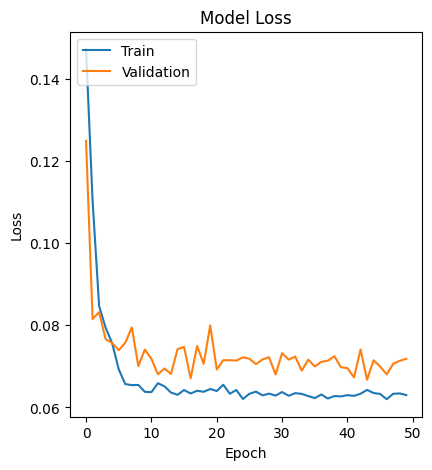

In [ ]:
def plot_history(history):

    plt.figure(figsize=(10, 5))

    # summarize history for loss
    plt.subplot(122)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Validation'], loc='upper left')

    plt.show()

print(history.history.keys())
plot_history(history)

## <font color=  #003366> **Image Generation**</font>

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step


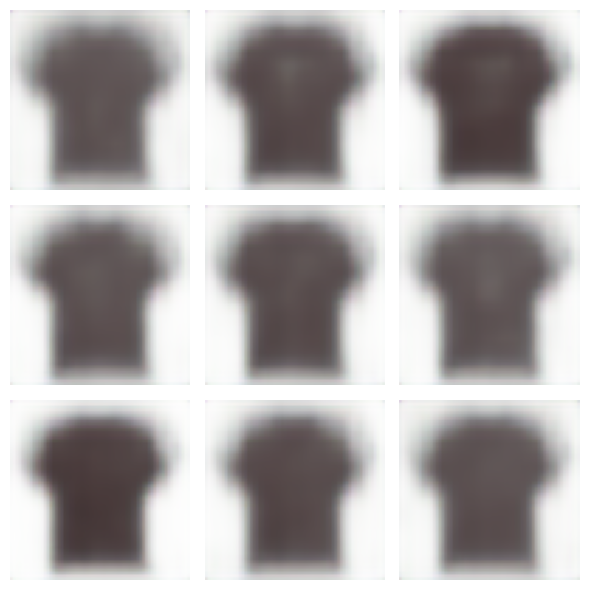

In [ ]:
random_latent_vectors = np.random.normal(size=(9, latent_dim))
generated_images = decoder.predict(random_latent_vectors)

plt.figure(figsize=(6,6))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(generated_images[i])
    plt.axis("off")
plt.tight_layout()
plt.show()


Even though the model reconstructs the T-shirt shape correctly, many generated images appear gray and very similar. This happens because the dataset is small and the model is trained using Mean Squared Error (MSE) loss.
MSE tends to average pixel values when there is uncertainty, which results in blurry and grayish outputs.
The model learns the average T-shirt instead of different colors.

## <font color=  #003366> **Metric**</font>

In [ ]:
reconstructed = vae.predict(X_test_norm)

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step


In [ ]:
import numpy as np

mse = np.mean((X_test_norm - reconstructed) ** 2)
print("Reconstruction MSE:", mse)

Reconstruction MSE: 0.06376084


## <font color=  #003366> **Next steps**</font>

The VAE architecture successfully compresses the images into a low dimensional latent space and reconstructs the general structure of T-shirts.

However, due to the small dataset size and the use of MSE loss, the model tends to generate average-looking and grayish images. Future improvements include increasing latent dimensionality, balancing KL divergence, and using perceptual metrics such as SSIM.